In [2]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, roc_auc_score, average_precision_score
)

import joblib

# Load dataset
df = pd.read_csv("final_dataset.csv")

print(df.shape)
df.head()

(10000, 16)


,UDI,Product Name,Type of Analysis,Instrument ID,Room Air temperature [K],Instrument temperature [K],Instrument Usage_hours,Runs_since_PM,Component_age_days,Days_since_last_PM,PM_overdue_flag,Room_temp_stability_issue,Power_fluctuation_flag,Minor_alarm_counts,Past_incidents_count,Date of Observation
0,1,Diazepam,Assay,UV Spec-11,298.1,308.6,396,301,511,164,0,0,0,5,1,12-01-2026
1,2,Ibuprofen,Dissolution,HPLC-6,298.2,308.7,864,14,838,58,0,0,0,9,5,06-01-2026
2,3,Ibuprofen,UV Spec,HPLC-2,298.1,308.5,1606,150,235,177,0,0,1,5,5,11-03-2026
3,4,Diazepam,Assay,HPLC-6,298.2,308.6,1849,491,607,58,0,0,0,7,5,29-01-2026
4,5,Atorvastatin,Dissolution,HPLC-2,298.2,308.7,1612,489,640,155,0,1,0,6,4,09-02-2026


In [4]:
df["Date of Observation"] = pd.to_datetime(df["Date of Observation"], dayfirst=True)

In [5]:
# Column shortcuts
air   = "Room Air temperature [K]"
proc  = "Instrument temperature [K]"
usage = "Instrument Usage_hours"
runs  = "Runs_since_PM"
age   = "Component_age_days"
days  = "Days_since_last_PM"
pm_overdue = "PM_overdue_flag"
temp_issue = "Room_temp_stability_issue"
power_issue = "Power_fluctuation_flag"
minor = "Minor_alarm_counts"
past  = "Past_incidents_count"

# Derived signals
Delta_T = df[proc] - df[air]

# Percentile thresholds
DELTA_LOW = np.percentile(Delta_T, 10)
AGE_HIGH  = np.percentile(df[age], 85)
USE_HIGH  = np.percentile(df[usage], 85)
RUNS_HIGH = np.percentile(df[runs], 85)
DAYS_HIGH = np.percentile(df[days], 85)

# Boolean triggers
temp_risk  = Delta_T <= DELTA_LOW
pm_risk    = (df[pm_overdue]==1) | (df[days]>=DAYS_HIGH) | (df[runs]>=RUNS_HIGH)
age_risk   = df[age] >= AGE_HIGH
use_risk   = df[usage] >= USE_HIGH
env_risk   = (df[temp_issue]==1) | (df[power_issue]==1)
inc_risk   = (df[minor] + df[past] >= 4)

# Weighted score
risk_score = (
    2*pm_risk +
    2*inc_risk +
    1*use_risk +
    1*age_risk +
    1*env_risk +
    1*temp_risk
).astype(int)

# Auto threshold to get ~20% failures
unique = sorted(np.unique(risk_score))
target = 0.20
best_threshold = min(unique, key=lambda t: abs((risk_score>=t).mean() - target))

df["Machine_failure"] = (risk_score >= best_threshold).astype(int)

df["Machine_failure"].value_counts(normalize=True)

Machine_failure
0    0.8299
1    0.1701
Name: proportion, dtype: float64

In [6]:
def add_engineered_features(X):
    X = X.copy()
    X["Delta_T"] = X["Instrument temperature [K]"] - X["Room Air temperature [K]"]
    X["PM_Risk"] = X["Days_since_last_PM"] + X["Runs_since_PM"]
    X["Incident_Risk"] = X["Minor_alarm_counts"] + X["Past_incidents_count"]
    return X

In [7]:
drop_cols = [
    "UDI",
    "Product Name",
    "Instrument ID",
    "Type of Analysis",
    "Date of Observation",
    "Machine_failure"
]

X = df.drop(columns=[c for c in drop_cols if c in df.columns])
X = add_engineered_features(X)

y = df["Machine_failure"]

X.shape, y.value_counts()

((10000, 14),
 Machine_failure
 0    8299
 1    1701
 Name: count, dtype: int64)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

preprocess = ColumnTransformer(
    transformers=[("num", StandardScaler(), X.columns)],
    remainder="drop"
)

rf = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

pipe = Pipeline([("prep", preprocess), ("model", rf)])
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices

In [9]:
proba = pipe.predict_proba(X_test)[:, 1]
pred  = (proba >= 0.50).astype(int)

print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_recall_fscore_support(y_test, pred, average="binary")[0])
print("Recall   :", precision_recall_fscore_support(y_test, pred, average="binary")[1])
print("F1       :", precision_recall_fscore_support(y_test, pred, average="binary")[2])
print("ROC-AUC  :", roc_auc_score(y_test, proba))
print("PR-AUC   :", average_precision_score(y_test, proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))

Accuracy : 0.9925
Precision: 1.0
Recall   : 0.9558823529411765
F1       : 0.9774436090225563
ROC-AUC  : 0.999215095676825
PR-AUC   : 0.9967272994210861
Confusion Matrix:
 [[1660    0]
 [  15  325]]


In [10]:
proba_all  = pipe.predict_proba(X)[:, 1]
health_all = ((1 - proba_all) * 100).round(0).astype(int)

In [11]:
df["Delta_T"] = df["Instrument temperature [K]"] - df["Room Air temperature [K]"]
df["PM_Risk"] = df["Days_since_last_PM"] + df["Runs_since_PM"]
df["Incident_Risk"] = df["Minor_alarm_counts"] + df["Past_incidents_count"]

In [12]:
def reason_for_health(row):
    reasons = []

    if row["Delta_T"] <= DELTA_LOW:
        reasons.append("Heat stress")

    if row["Instrument Usage_hours"] >= USE_HIGH:
        reasons.append("High usage")

    if row["Component_age_days"] >= AGE_HIGH:
        reasons.append("Old components")

    if row["Days_since_last_PM"] >= DAYS_HIGH or row["PM_overdue_flag"] == 1:
        reasons.append("PM overdue")

    if row["Minor_alarm_counts"] + row["Past_incidents_count"] >= 4:
        reasons.append("Many incidents")

    if row["Room_temp_stability_issue"]==1 or row["Power_fluctuation_flag"]==1:
        reasons.append("Env issues")

    return ", ".join(reasons[:2]) if reasons else "Healthy"

In [13]:
row_output = pd.DataFrame({
    "Instrument ID": df["Instrument ID"],
    "Date": df["Date of Observation"],
    "Health%": health_all,
    "Reason": df.apply(reason_for_health, axis=1)
})

In [14]:
# Sort by date
row_output_sorted = row_output.sort_values(["Instrument ID", "Date"], ascending=[True, False])

# Take LAST 10 rows per instrument
last10 = row_output_sorted.groupby("Instrument ID").head(10)

# Aggregate
instrument_final = last10.groupby("Instrument ID").agg({
    "Health%": "mean",
    "Reason": lambda x: x.mode()[0],   # most frequent reason in last 10
    "Date": "max"                      # most recent observation date
}).reset_index()

# Round health%
instrument_final["Health%"] = instrument_final["Health%"].round(0).astype(int)

# Save
instrument_final.to_csv("instrument_health_final_per_instrument.csv", index=False)

instrument_final.head(20)

,Instrument ID,Health%,Reason,Date
0,Disso-1,80,Many incidents,2026-03-21
1,Disso-2,89,Many incidents,2026-03-21
2,Disso-3,97,Many incidents,2026-03-21
3,Disso-4,97,Many incidents,2026-03-21
4,Disso-5,87,Many incidents,2026-03-21
5,Disso-6,89,Many incidents,2026-03-21
6,Disso-7,79,"Old components, Many incidents",2026-03-21
7,HPLC-1,86,Many incidents,2026-03-21
8,HPLC-2,95,Many incidents,2026-03-21
9,HPLC-3,90,Many incidents,2026-03-21


Matplotlib is building the font cache; this may take a moment.


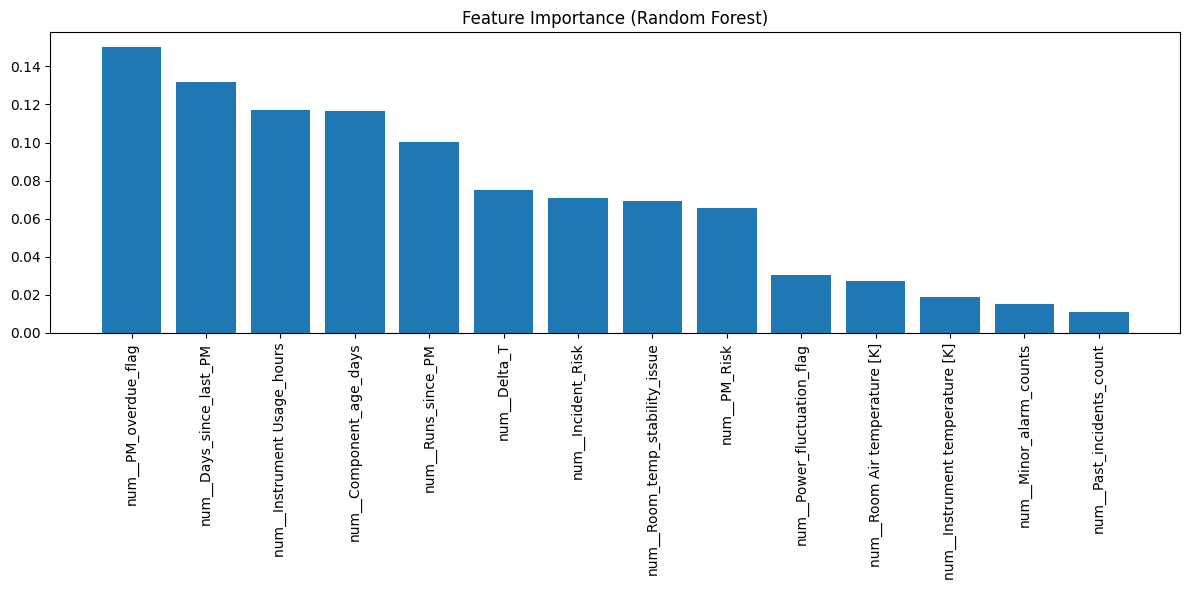

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Extract feature names after preprocessing
feature_names = pipe.named_steps["prep"].get_feature_names_out()

# Extract feature importances from the RandomForest model
importances = pipe.named_steps["model"].feature_importances_

# Sort by importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12,6))
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.title("Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

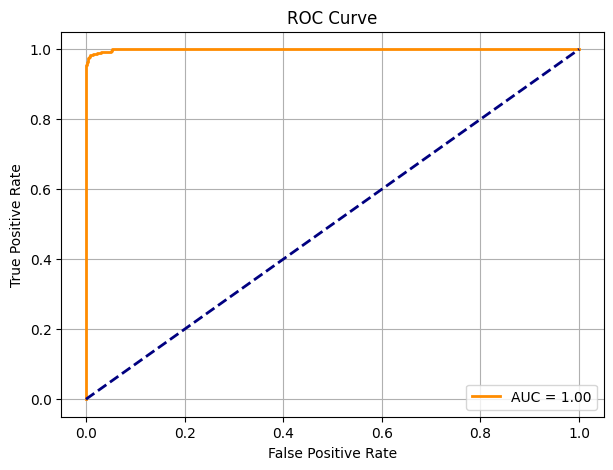

In [16]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid()
plt.show()

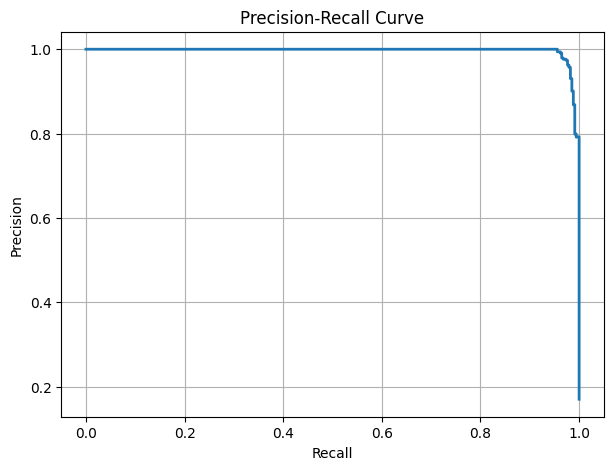

In [17]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, proba)

plt.figure(figsize=(7,5))
plt.plot(recall, precision, lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()
plt.show()

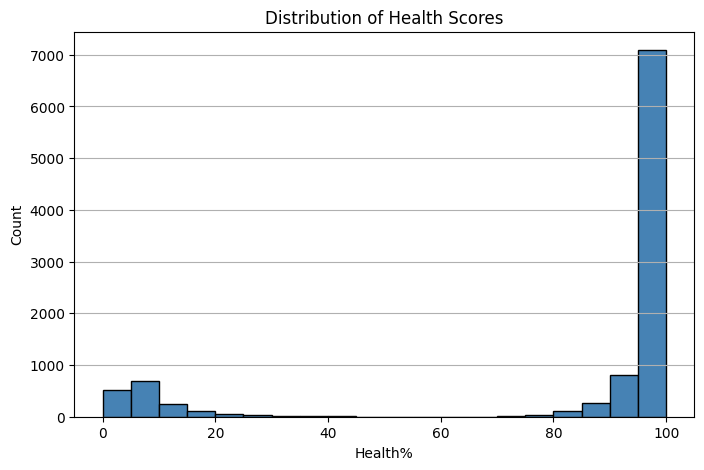

In [18]:
plt.figure(figsize=(8,5))
plt.hist(health_all, bins=20, color="steelblue", edgecolor="black")
plt.title("Distribution of Health Scores")
plt.xlabel("Health%")
plt.ylabel("Count")
plt.grid(axis='y')
plt.show()

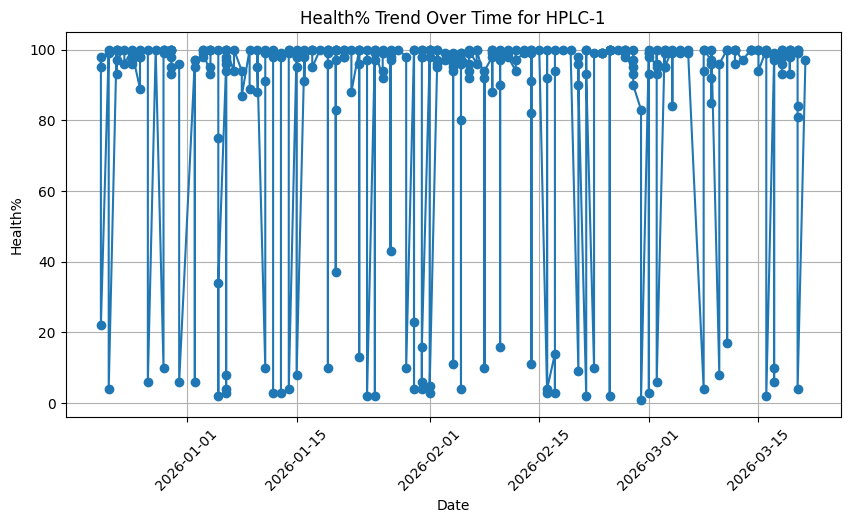

In [19]:
sample_id = "HPLC-1"   # change to any instrument ID
sample = row_output[row_output["Instrument ID"] == sample_id].sort_values("Date")

plt.figure(figsize=(10,5))
plt.plot(sample["Date"], sample["Health%"], marker='o')
plt.title(f"Health% Trend Over Time for {sample_id}")
plt.xlabel("Date")
plt.ylabel("Health%")
plt.grid()
plt.xticks(rotation=45)
plt.show()

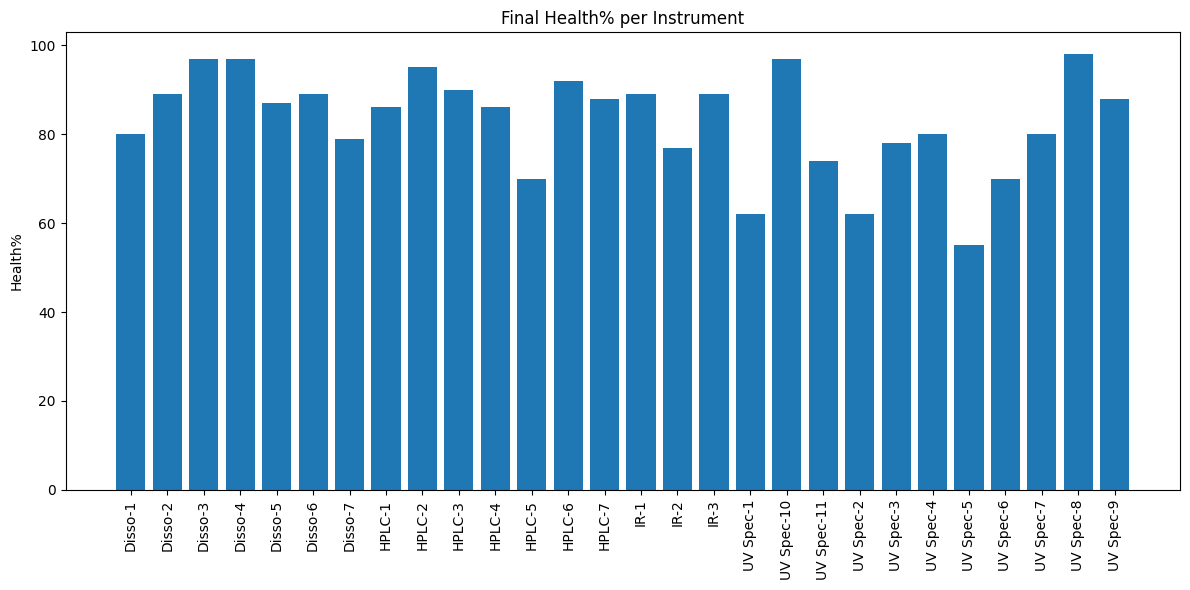

In [20]:
plt.figure(figsize=(12,6))
plt.bar(instrument_final["Instrument ID"], instrument_final["Health%"])
plt.xticks(rotation=90)
plt.ylabel("Health%")
plt.title("Final Health% per Instrument")
plt.tight_layout()
plt.show()